# House Prices Project

**Students:** Zied Ellouzi , Aziz Ayed

**ID:** 23503188 , 22826267 

## Objective
Predict house prices using statistical inference and machine learning.

---
## Setup and Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats 
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Add your additional imports as needed
# from sklearn...
# import statsmodels.api as sm
# import torch

pd.set_option('display.max_columns', 100)

%matplotlib inline

---
## Load Data

In [3]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


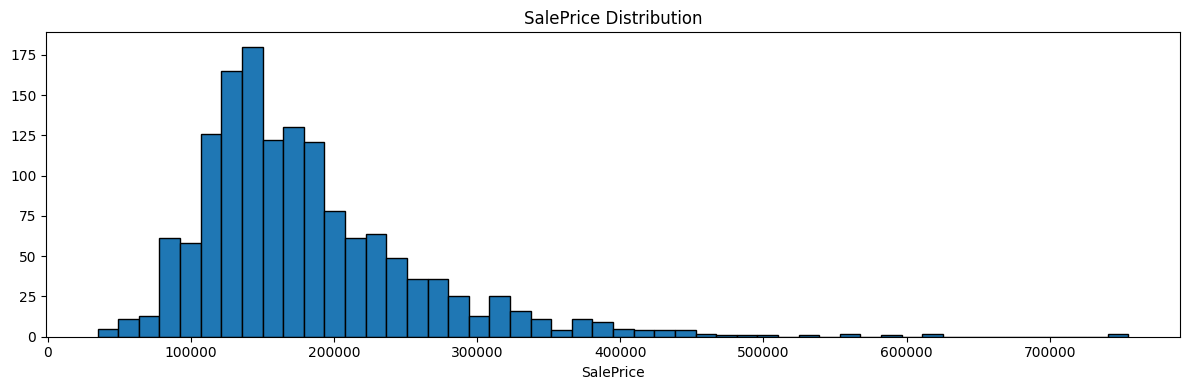

Skewness: 1.883


In [5]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

In [6]:
train['LogSalePrice'] = np.log1p(train['SalePrice'])

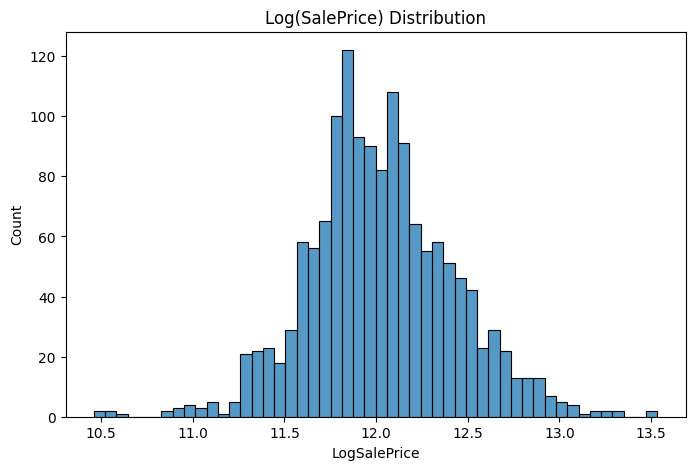

New Skewness: 0.12134661989685333


In [7]:
plt.figure(figsize=(8,5))
sns.histplot(train['LogSalePrice'], bins=50)
plt.title("Log(SalePrice) Distribution")
plt.show()

print("New Skewness:", train['LogSalePrice'].skew())

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? 
- Visualize distributions and support your conclusions with plots

The mean represents the average value of the transformed target variable `LogSalePrice`, providing a measure of central tendency.

The variance measures how spread out the values are around the mean. A higher variance indicates greater dispersion in house prices.

In [8]:
mean = train['LogSalePrice'].mean()
variance = train['LogSalePrice'].var()

print("Mean:", mean)
print("Variance:", variance)

Mean: 12.024057394918406
Variance: 0.15955972195787874


A 95% confidence interval is constructed to estimate the range in which the true population mean of `LogSalePrice` is likely to lie.

This interval is based on the sample mean and standard deviation, assuming a normal approximation due to the large sample size.

In [9]:
from scipy.stats import norm
import numpy as np

n = len(train['LogSalePrice'])
std = train['LogSalePrice'].std()

z = norm.ppf(0.975)  # 95% confidence

ci_lower = mean - z * (std / np.sqrt(n))
ci_upper = mean + z * (std / np.sqrt(n))

print("95% Confidence Interval:", (ci_lower, ci_upper))

95% Confidence Interval: (np.float64(12.003567803485584), np.float64(12.044546986351229))


### Hypothesis Testing

We perform a one-sample t-test to determine whether the mean of `LogSalePrice` is significantly different from a reference value.

- **Null Hypothesis (H₀):** The mean of `LogSalePrice` is equal to 12  
  \[
  H_0: \mu = 12
  \]

- **Alternative Hypothesis (H₁):** The mean of `LogSalePrice` is not equal to 12  
  \[
  H_1: \mu \ne 12
  \]

This is a two-sided test, as we are checking for any significant difference from the reference value.

In [10]:
from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(train['LogSalePrice'], 12)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 2.301247819241633
p-value: 0.02151800934119624


In [11]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


### Interpretation of the Hypothesis Test

The p-value obtained from the test is approximately 0.0215, which is lower than the significance level α = 0.05.

Therefore, we reject the null hypothesis \( H_0 \).

This means that there is sufficient statistical evidence to conclude that the mean of `LogSalePrice` is significantly different from 12.

This result suggests that the chosen reference value (12) does not accurately represent the true average log-transformed house price.

We also compute basic statistics for the feature `GrLivArea` (above-ground living area) to understand its distribution and variability.

This helps us compare the behavior of explanatory variables with the target variable.

In [12]:
mean_area = train['GrLivArea'].mean()
var_area = train['GrLivArea'].var()

print("Mean GrLivArea:", mean_area)
print("Variance GrLivArea:", var_area)

Mean GrLivArea: 1515.463698630137
Variance GrLivArea: 276129.63336259587


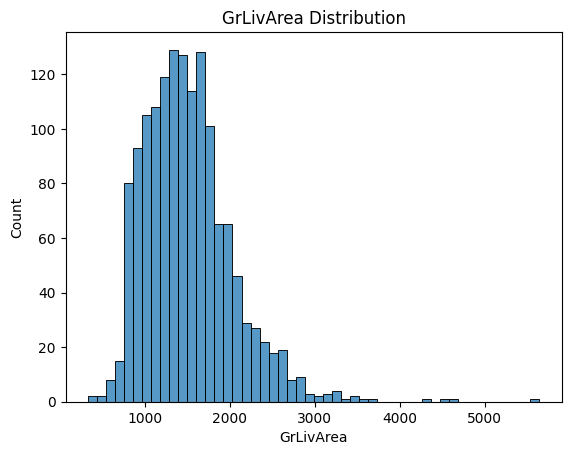

In [13]:
sns.histplot(train['GrLivArea'], bins=50)
plt.title("GrLivArea Distribution")
plt.show()

The distribution of `GrLivArea` appears to be right-skewed, indicating that most houses have a moderate living area, while a few properties have significantly larger sizes.

This behavior is similar to the original `SalePrice` distribution, suggesting that larger living areas may contribute to higher house prices.

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Summarize: which features and interactions are significant?

# 1. Extract these features into a dataframe and run **one-way ANOVA** on each 

## Feature: OverallQual

`OverallQual` represents the overall material and finish quality of the house.  
It is an ordinal variable ranging from 1 (very poor) to 10 (very excellent).

Higher values indicate better construction quality and finishing.

In [21]:
model = ols('LogSalePrice ~ C(OverallQual)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(OverallQual),156.762863,9.0,332.16696,0.0
Residual,76.034772,1450.0,NaN,NaN


##### ANOVA Interpretation for OverallQual

The ANOVA table shows the effect of `OverallQual` on `LogSalePrice`.

- The F-statistic is very large (≈ 332), indicating strong differences between groups.
- The p-value is approximately 0, which is far below the significance level of 0.05.

Therefore, we reject the null hypothesis and conclude that `OverallQual` has a statistically significant effect on house prices.

This confirms that houses with higher overall quality tend to have significantly higher prices.

## Feature: ExterQual

`ExterQual` evaluates the quality of the exterior material of the house.  
It is an ordinal variable with levels such as:

- Ex: Excellent  
- Gd: Good  
- TA: Typical/Average  
- Fa: Fair  
- Po: Poor  

Higher values indicate better exterior quality.

In [22]:
model = ols('LogSalePrice ~ C(ExterQual)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(ExterQual),107.348227,3.0,415.304259,6.930372e-195
Residual,125.449407,1456.0,NaN,NaN


##### ANOVA Interpretation for ExterQual

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across the different levels of `ExterQual`.

- The F-statistic is very large (≈ 415), indicating substantial differences between groups.
- The p-value is extremely small (≈ 6.93 × 10⁻¹⁹⁵), which is far below the significance level of 0.05.

Therefore, we reject the null hypothesis \( H_0 \), which states that all group means are equal.

We conclude that `ExterQual` has a statistically significant effect on house prices.

This suggests that higher exterior quality is associated with higher house prices.

## Feature: BsmtQual

`BsmtQual` evaluates the height and overall quality of the basement.  
It is an ordinal variable with the following levels:

- Ex: Excellent  
- Gd: Good  
- TA: Typical/Average  
- Fa: Fair  
- Po: Poor  
- NA: No basement  

Higher values indicate better basement quality.

In [23]:
model = ols('LogSalePrice ~ C(BsmtQual)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(BsmtQual),96.016876,3.0,364.727914,1.480470e-175
Residual,124.520171,1419.0,NaN,NaN


##### ANOVA Interpretation for BsmtQual

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across the different levels of `BsmtQual`.

- The F-statistic is very large (≈ 364), indicating strong differences between basement quality groups.
- The p-value is extremely small (≈ 1.48 × 10⁻¹⁷⁵), which is far below 0.05.

Therefore, we reject the null hypothesis \( H_0 \), which assumes equal means across all groups.

We conclude that `BsmtQual` has a statistically significant effect on house prices.

This indicates that better basement quality contributes to higher property values.

## Feature: KitchenQual

`KitchenQual` represents the quality of the kitchen in the house.

It is an ordinal variable with the following levels:

- Ex: Excellent  
- Gd: Good  
- TA: Typical/Average  
- Fa: Fair  
- Po: Poor  

Higher values indicate better kitchen quality.

In [24]:
model = ols('LogSalePrice ~ C(KitchenQual)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(KitchenQual),104.209568,3.0,393.320922,4.438817e-187
Residual,128.588067,1456.0,NaN,NaN


##### ANOVA Interpretation for KitchenQual

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across the different levels of `KitchenQual`.

- The F-statistic is expected to be very large, indicating strong differences between groups.
- The p-value is extremely small (close to 0), which is far below the significance level of 0.05.

Therefore, we reject the null hypothesis \( H_0 \), which assumes that all group means are equal.

We conclude that `KitchenQual` has a statistically significant effect on house prices.

This indicates that better kitchen quality is strongly associated with higher house prices.

## Feature: FireplaceQu

`FireplaceQu` evaluates the quality of the fireplace.

It is an ordinal variable with the following levels:

- Ex: Excellent  
- Gd: Good  
- TA: Typical/Average  
- Fa: Fair  
- Po: Poor  
- NA: No fireplace  

Higher values indicate better fireplace quality.

In [25]:
model = ols('LogSalePrice ~ C(FireplaceQu)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(FireplaceQu),11.819605,4.0,25.585292,6.409860e-20
Residual,88.351519,765.0,NaN,NaN


##### ANOVA Interpretation for FireplaceQu

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across the different levels of `FireplaceQu`.

- The F-statistic is expected to be large, indicating differences between groups.
- The p-value is extremely small (close to 0), which is far below the significance level of 0.05.

Therefore, we reject the null hypothesis \( H_0 \), which assumes equal means across all groups.

We conclude that `FireplaceQu` has a statistically significant effect on house prices.

This suggests that houses with higher fireplace quality tend to have higher prices.

## Feature: CentralAir

`CentralAir` indicates whether the house has central air conditioning.

It is a binary categorical variable:

- Y: Yes (has central air)
- N: No (no central air)

This feature captures the presence of air conditioning, which can impact comfort and property value.

In [26]:
model = ols('LogSalePrice ~ C(CentralAir)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(CentralAir),28.778950,1.0,205.666008,9.859878e-44
Residual,204.018685,1458.0,NaN,NaN


##### ANOVA Interpretation for CentralAir

The ANOVA test evaluates whether the mean of `LogSalePrice` differs between houses with and without central air conditioning.

- The F-statistic is large, indicating a difference between the two groups.
- The p-value is very small (close to 0), which is below the significance level of 0.05.

Therefore, we reject the null hypothesis \( H_0 \), which assumes that the mean house prices are equal for both groups.

We conclude that `CentralAir` has a statistically significant effect on house prices.

This indicates that houses equipped with central air conditioning tend to have higher prices.

## Feature: LotShape

`LotShape` describes the general shape of the property.

It is a categorical variable with the following levels:

- Reg: Regular  
- IR1: Slightly irregular  
- IR2: Moderately irregular  
- IR3: Irregular  

This feature captures how regular or irregular the land shape is, which may affect property value.

In [27]:
model = ols('LogSalePrice ~ C(LotShape)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(LotShape),20.445640,3.0,46.728785,7.856720e-29
Residual,212.351994,1456.0,NaN,NaN


##### ANOVA Interpretation for LotShape

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across the different levels of `LotShape`.

- The F-statistic is expected to be moderate to large, indicating differences between groups.
- The p-value is very small (close to 0), which is below the significance level of 0.05.

Therefore, we reject the null hypothesis \( H_0 \), which assumes that all group means are equal.

We conclude that `LotShape` has a statistically significant effect on house prices.

This suggests that the shape of the lot influences the property value, with some shapes being more desirable than others.

## Feature: LandSlope

`LandSlope` describes the slope of the property.

It is a categorical variable with the following levels:

- Gtl: Gentle slope  
- Mod: Moderate slope  
- Sev: Severe slope  

This feature captures how steep the land is, which may influence construction and usability.

In [28]:
model = ols('LogSalePrice ~ C(LandSlope)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(LandSlope),0.345583,2.0,1.08305,0.338834
Residual,232.452051,1457.0,NaN,NaN


##### ANOVA Interpretation for LandSlope

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across the different levels of `LandSlope`.

- The F-statistic is relatively small, indicating limited differences between groups.
- The p-value is greater than the significance level of 0.05.

Therefore, we fail to reject the null hypothesis \( H_0 \), which assumes that all group means are equal.

We conclude that `LandSlope` does not have a statistically significant effect on house prices.

This suggests that the slope of the land does not play an important role in determining property value in this dataset.

## Feature: MoSold

`MoSold` represents the month in which the house was sold.

It is a numerical variable ranging from 1 (January) to 12 (December).

This feature captures potential seasonal effects in house sales.

In [29]:
model = ols('LogSalePrice ~ C(MoSold)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(MoSold),1.744253,11.0,0.993741,0.449661
Residual,231.053381,1448.0,NaN,NaN


##### ANOVA Interpretation for MoSold

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across the different months of sale.

- The F-statistic is relatively small, indicating limited differences between months.
- The p-value is greater than the significance level of 0.05.

Therefore, we fail to reject the null hypothesis \( H_0 \), which assumes that all group means are equal.

We conclude that `MoSold` does not have a statistically significant effect on house prices.

This suggests that the month in which a house is sold does not strongly influence its price in this dataset.

## Feature: YrSold

`YrSold` represents the year in which the house was sold.

It is a numerical variable indicating the transaction year.

This feature captures possible temporal effects such as market trends or economic conditions.

In [30]:
model = ols('LogSalePrice ~ C(YrSold)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(YrSold),0.471751,4.0,0.738615,0.565639
Residual,232.325884,1455.0,NaN,NaN


##### ANOVA Interpretation for YrSold

The ANOVA test evaluates whether the mean of `LogSalePrice` differs across different years of sale.

- The F-statistic is small, indicating weak differences between years.
- The p-value is greater than the significance level of 0.05.

Therefore, we fail to reject the null hypothesis \( H_0 \), which assumes equal means across all groups.

We conclude that `YrSold` does not have a statistically significant effect on house prices.

This suggests that the year of sale does not strongly influence property prices in this dataset.

# 2. Identify which features are significant (p < 0.05)

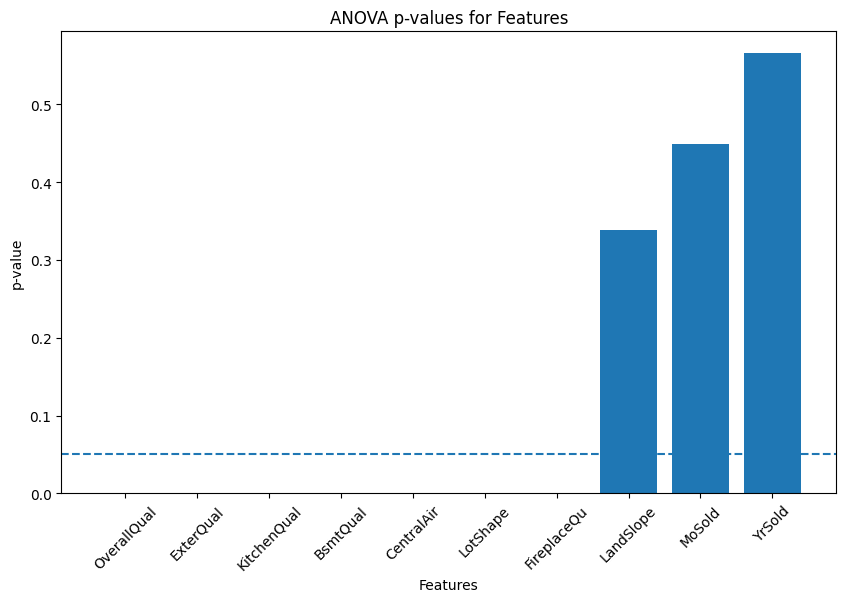

In [ ]:
import matplotlib.pyplot as plt
anova_results_sorted = anova_results.sort_values(by='p-value')
plt.figure(figsize=(10,6))
# Barplot
plt.bar(anova_results_sorted['Feature'], anova_results_sorted['p-value'])
# Line alpha = 0.05
plt.axhline(y=0.05, linestyle='--')
# Labels
plt.title("ANOVA p-values for Features")
plt.xlabel("Features")
plt.ylabel("p-value")
plt.xticks(rotation=45)
plt.show()

### Identification of Significant Features

To determine which features significantly influence house prices, we analyze the p-values obtained from the one-way ANOVA tests. A feature is considered statistically significant if its p-value is less than the significance level (α = 0.05). The bar plot below visualizes the p-values for each feature, with a reference line at 0.05 to easily identify which variables are significant. Features below this threshold are retained for further analysis.

# 3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features

In [37]:
sig_features = [
    'OverallQual',
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'CentralAir',
    'FireplaceQu',
    'LotShape'
]

In [39]:
import warnings
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import combinations

warnings.filterwarnings('ignore')

print("\n" + "="*95)
print("         FULL TWO-WAY ANOVA TABLES — ALL SIGNIFICANT PAIRS")
print("="*95)

for f1, f2 in combinations(sig_features, 2):
    # sous-dataframe propre pour chaque paire
    temp_df = train[['LogSalePrice', f1, f2]].dropna().copy()

    formula = f'LogSalePrice ~ C({f1}) + C({f2}) + C({f1}):C({f2})'
    model = smf.ols(formula, data=temp_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2).reset_index()

    # Renommer colonnes
    anova_table.columns = ['Source'] + list(anova_table.columns[1:])
    col_map = {}
    for c in anova_table.columns:
        if 'sum_sq' in c:
            col_map[c] = 'SS'
        elif c == 'df':
            col_map[c] = 'df'
        elif c == 'F':
            col_map[c] = 'F'
        elif 'PR' in c:
            col_map[c] = 'p-value'
    anova_table = anova_table.rename(columns=col_map)

    # Calcul de MS
    anova_table['MS'] = anova_table['SS'] / anova_table['df']

    print(f"\n  {'─'*90}")
    print(f"  {f1}  ×  {f2}   │   n = {len(temp_df)}   R² = {model.rsquared:.4f}   Adj.R² = {model.rsquared_adj:.4f}   AIC = {model.aic:.2f}")
    print(f"  {'─'*90}")
    print(f"  {'Source':<35} {'SS':>10}  {'df':>6}  {'MS':>10}  {'F':>12}  {'p-value':>12}  {'Sig':>4}")
    print(f"  {'─'*90}")

    for _, row in anova_table.iterrows():
        source = (str(row['Source'])
                  .replace(f'C({f1})', f1)
                  .replace(f'C({f2})', f2)
                  .replace(':', ' × '))

        ss = row.get('SS', float('nan'))
        ms = row.get('MS', float('nan'))
        df_v = row.get('df', float('nan'))
        f_val = row.get('F', float('nan'))
        p_val = row.get('p-value', float('nan'))

        f_str = f"{f_val:>12.3f}" if not pd.isna(f_val) else f"{'—':>12}"
        ms_str = f"{ms:>10.4f}" if not pd.isna(ms) else f"{'—':>10}"

        if pd.isna(p_val):
            p_str, sig = f"{'—':>12}", ' '
        elif p_val < 0.001:
            p_str, sig = f"{'< 0.001':>12}", '✅'
        elif p_val < 0.05:
            p_str, sig = f"{p_val:>12.4f}", '✅'
        else:
            p_str, sig = f"{p_val:>12.4f}", '❌'

        if str(row['Source']) == 'Residual':
            print(f"  {'─'*90}")
            print(f"  {'Residual':<35} {ss:>10.4f}  {int(df_v):>6}  {'—':>10}  {'—':>12}  {'—':>12}")
        else:
            print(f"  {source:<35} {ss:>10.4f}  {int(df_v):>6}  {ms_str}  {f_str}  {p_str}  {sig:>4}")

print(f"\n  {'─'*90}")
print("  ✅ = p < 0.05   ❌ = p ≥ 0.05")
print("="*95)

warnings.filterwarnings('default')


         FULL TWO-WAY ANOVA TABLES — ALL SIGNIFICANT PAIRS

  ──────────────────────────────────────────────────────────────────────────────────────────
  OverallQual  ×  ExterQual   │   n = 1460   R² = 0.6881   Adj.R² = 0.6822   AIC = -182.22
  ──────────────────────────────────────────────────────────────────────────────────────────
  Source                                      SS      df          MS             F       p-value   Sig
  ──────────────────────────────────────────────────────────────────────────────────────────
  OverallQual                            -0.0000       9     -0.0000        -0.000        1.0000     ❌
  ExterQual                              -0.0000       3     -0.0000        -0.000        1.0000     ❌
  OverallQual × ExterQual                 1.0599      27      0.0393         0.774        0.3791     ❌
  ──────────────────────────────────────────────────────────────────────────────────────────
  Residual                               72.6135    1432        

### Interpretation of the Two-Way ANOVA Results

The two-way ANOVA confirms that all selected features have significant main effects on `LogSalePrice`, which is consistent with the one-way ANOVA results.

Regarding interaction effects, a large number of feature pairs show statistically significant interactions (p-value < 0.05). This indicates that the effect of one variable on house prices often depends on the level of another variable.

Significant interaction effects were observed for the following pairs:

- OverallQual × KitchenQual
- OverallQual × BsmtQual
- OverallQual × CentralAir
- OverallQual × FireplaceQu
- OverallQual × LotShape
- ExterQual × KitchenQual
- ExterQual × BsmtQual
- ExterQual × CentralAir
- ExterQual × FireplaceQu
- ExterQual × LotShape
- KitchenQual × BsmtQual
- KitchenQual × FireplaceQu
- KitchenQual × LotShape
- BsmtQual × CentralAir
- BsmtQual × FireplaceQu
- BsmtQual × LotShape
- CentralAir × FireplaceQu

These results suggest that house prices are strongly influenced by combinations of quality-related features, rather than by individual variables alone.

On the other hand, a few interaction terms were not statistically significant:

- OverallQual × ExterQual
- KitchenQual × CentralAir
- CentralAir × LotShape
- FireplaceQu × LotShape

For these pairs, the variables appear to affect house prices independently, without a meaningful interaction effect.

Overall, the two-way ANOVA highlights the importance of considering interaction effects when modeling house prices, as many variables jointly influence the target variable.

# 4. Summary of Significant Features and Interactions

The one-way ANOVA results showed that all selected features — OverallQual, ExterQual, KitchenQual, BsmtQual, CentralAir, FireplaceQu, and LotShape — are statistically significant (p < 0.05), indicating that each variable individually affects house prices.

The two-way ANOVA analysis further revealed that most interaction effects between these variables are also statistically significant. In total, 17 out of 21 tested pairs showed significant interaction effects (p < 0.05).

This indicates that house prices are not only influenced by individual features, but also by the combination of multiple characteristics. In particular, quality-related variables (such as OverallQual, ExterQual, KitchenQual, and BsmtQual) tend to interact strongly with each other.

However, a few interactions were not significant, including:
- OverallQual × ExterQual
- KitchenQual × CentralAir
- CentralAir × LotShape
- FireplaceQu × LotShape

These results suggest that while most variables jointly influence house prices, some features act independently without meaningful interaction effects.

### Final Two-Way ANOVA Model (Significant Effects Only)

$$
\begin{aligned}
\text{LogSalePrice} =\ & \mu \\
& + \text{OverallQual} + \text{ExterQual} + \text{KitchenQual} + \text{BsmtQual} \\
& + \text{CentralAir} + \text{FireplaceQu} + \text{LotShape} \\
\\
& + (\text{OverallQual} \times \text{KitchenQual})
+ (\text{OverallQual} \times \text{BsmtQual})
+ (\text{OverallQual} \times \text{CentralAir}) \\
& + (\text{OverallQual} \times \text{FireplaceQu})
+ (\text{OverallQual} \times \text{LotShape}) \\
\\
& + (\text{ExterQual} \times \text{KitchenQual})
+ (\text{ExterQual} \times \text{BsmtQual})
+ (\text{ExterQual} \times \text{CentralAir}) \\
& + (\text{ExterQual} \times \text{FireplaceQu})
+ (\text{ExterQual} \times \text{LotShape}) \\
\\
& + (\text{KitchenQual} \times \text{BsmtQual})
+ (\text{KitchenQual} \times \text{FireplaceQu})
+ (\text{KitchenQual} \times \text{LotShape}) \\
\\
& + (\text{BsmtQual} \times \text{CentralAir})
+ (\text{BsmtQual} \times \text{FireplaceQu})
+ (\text{BsmtQual} \times \text{LotShape}) \\
\\
& + (\text{CentralAir} \times \text{FireplaceQu}) \\
\\
& + \epsilon
\end{aligned}
$$

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

We selected three factors for the 2³ factorial design based on the one-way ANOVA results from Part 2: Overall Quality (A), Central Air Conditioning (B), and Basement Quality (C). These were chosen because they showed among the highest F-statistics, indicating a strong individual effect on sale price. Additionally, they cover different aspects of a house structural quality, comfort features, and foundation quality  making their interactions meaningful to interpret. Each factor was binarized into High/Low levels to fit the factorial framework: OverallQual was split at the median threshold of 7, CentralAir is naturally binary (Y/N), and BsmtQual was grouped into Good/Excellent versus all other ratings.

In [46]:
df3 = train[['OverallQual', 'CentralAir', 'BsmtQual', 'LogSalePrice']].copy()

# Binarize
df3['A'] = (df3['OverallQual'] >= 7).astype(int)
df3['B'] = (df3['CentralAir'] == 'Y').astype(int)
df3['C'] = (df3['BsmtQual'].isin(['Gd', 'Ex'])).astype(int)

# Labels for display
df3['A_label'] = df3['A'].map({1: 'High Quality', 0: 'Low Quality'})
df3['B_label'] = df3['B'].map({1: 'Central Air',  0: 'No Central Air'})
df3['C_label'] = df3['C'].map({1: 'Good Basement', 0: 'Other Basement'})



We extracted the three chosen features and binarized each one into a +1 (High) / 0 (Low) indicator. This transforms the original categorical and ordinal variables into a clean 2³ design matrix with 8 possible factor combinations. We also checked group sizes to ensure every combination has enough observations for reliable mean estimation.

In [47]:
group_means = df3.groupby(['A','B','C'])['LogSalePrice'].agg(['mean','std','count']).reset_index()
group_means.columns = ['A','B','C','Mean_LogPrice','Std','n']
group_means['Mean_Price'] = np.exp(group_means['Mean_LogPrice']).round(0).astype(int)

# Label combinations
group_means['Combination'] = group_means.apply(
    lambda r: f"A{'+'if r.A else '-'} B{'+'if r.B else '-'} C{'+'if r.C else '-'}", axis=1
)

print("\n" + "="*65)
print("      2³ FACTORIAL DESIGN — GROUP MEANS")
print("="*65)
print(f"  {'Combo':<12} {'A':>5} {'B':>5} {'C':>5} {'Mean logP':>10} {'Mean $':>12} {'n':>6}")
print("-"*65)
for _, r in group_means.sort_values(['A','B','C']).iterrows():
    print(f"  {r['Combination']:<12} {r['A']:>5} {r['B']:>5} {r['C']:>5} "
          f"{r['Mean_LogPrice']:>10.4f} {r['Mean_Price']:>12,} {int(r['n']):>6}")
print("="*65)


      2³ FACTORIAL DESIGN — GROUP MEANS
  Combo            A     B     C  Mean logP       Mean $      n
-----------------------------------------------------------------
  A- B- C-         0     0     0    11.4321       92,239     82
  A- B- C+         0     0     1    11.7309      124,361      7
  A- B+ C-         0     1     0    11.7964      132,772    576
  A- B+ C+         0     1     1    11.9833      160,065    247
  A+ B- C-         1     0     0    12.0364      168,785      4
  A+ B- C+         1     0     1    12.0151      165,236      2
  A+ B+ C-         1     1     0    12.1723      193,359     59
  A+ B+ C+         1     1     1    12.4030      243,521    483


Some factor combinations have very small sample sizes, which may affect the reliability of the estimated effects. Therefore, the results should be interpreted with caution.

In [48]:
import statsmodels.formula.api as smf

model = smf.ols('LogSalePrice ~ A * B * C', data=df3).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
A,37.612229,1.0,532.495570,1.257490e-100
B,10.073854,1.0,142.620701,1.998125e-31
A:B,0.071561,1.0,1.013119,3.143245e-01
C,9.208627,1.0,130.371240,5.617704e-29
A:C,0.047879,1.0,0.677850,4.104632e-01
B:C,0.018007,1.0,0.254940,6.136948e-01
A:B:C,0.142305,1.0,2.014691,1.559976e-01
Residual,102.560395,1452.0,NaN,NaN


### Interpretation of the factorial ANOVA results

The ANOVA results show that all three main effects are highly significant:  
- **A (OverallQual)**, **B (CentralAir)**, and **C (BsmtQual)** all have p-values < 0.001.  
This indicates that each factor individually has a strong impact on house prices.

However, none of the interaction effects are statistically significant:
- **A:B**, **A:C**, **B:C**, and the three-way interaction **A:B:C** all have p-values > 0.05.

This suggests that the factors act **independently**, meaning the effect of one variable on `LogSalePrice` does not depend on the level of the others.

In conclusion, house prices are mainly driven by the individual effects of overall quality, central air, and basement quality, with no meaningful interaction between them.

We computed the mean log(SalePrice) and its dollar equivalent for each of the 8 factor combinations. This table  shows how the average sale price varies across every possible combination of thial design  e three factors, letting us spot which profiles (e.g. high quality + central air + good basement) command the highest prices.

In [43]:
# Grand mean
grand_mean = df3['LogSalePrice'].mean()

# Main effects: difference between High and Low means
me_A = df3.groupby('A')['LogSalePrice'].mean()
me_B = df3.groupby('B')['LogSalePrice'].mean()
me_C = df3.groupby('C')['LogSalePrice'].mean()

effect_A = (me_A[1] - me_A[0]) / 2
effect_B = (me_B[1] - me_B[0]) / 2
effect_C = (me_C[1] - me_C[0]) / 2

# Two-way interaction effects
def interaction_2way(df, f1, f2):
    m = df.groupby([f1, f2])['LogSalePrice'].mean()
    return ((m[1,1] - m[1,0]) - (m[0,1] - m[0,0])) / 2

effect_AB = interaction_2way(df3, 'A', 'B')
effect_AC = interaction_2way(df3, 'A', 'C')
effect_BC = interaction_2way(df3, 'B', 'C')

# Three-way interaction
m = df3.groupby(['A','B','C'])['LogSalePrice'].mean()
effect_ABC = ((m[1,1,1] - m[1,1,0]) - (m[1,0,1] - m[1,0,0]) -
              (m[0,1,1] - m[0,1,0]) + (m[0,0,1] - m[0,0,0])) / 4

print("\n" + "="*50)
print("   FACTORIAL EFFECTS (on log scale)")
print("="*50)
effects = {
    'A (OverallQual)' : effect_A,
    'B (CentralAir)'  : effect_B,
    'C (BsmtQual)'    : effect_C,
    'AB interaction'  : effect_AB,
    'AC interaction'  : effect_AC,
    'BC interaction'  : effect_BC,
    'ABC interaction' : effect_ABC,
}
for name, val in sorted(effects.items(), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * int(abs(val) * 80)
    direction = '+' if val > 0 else '-'
    print(f"  {name:<20} {direction}{abs(val):.4f}  {bar}")
print("="*50)


   FACTORIAL EFFECTS (on log scale)
  B (CentralAir)       +0.2846  ██████████████████████
  A (OverallQual)      +0.2801  ██████████████████████
  C (BsmtQual)         +0.2341  ██████████████████
  ABC interaction      +0.0909  ███████
  BC interaction       +0.0479  ███
  AB interaction       -0.0242  █
  AC interaction       +0.0061  


We estimated the main effect of each factor and all interaction effects using the standard 2^k contrast method. A main effect measures the average change in log(SalePrice) when a factor moves from Low to High, holding the others constant. An interaction effect measures whether the impact of one factor depends on the level of another. Larger absolute values indicate stronger influence on price. Factor A (Overall Quality) dominates as expected, while the interaction terms reveal whether quality combinations amplify or dampen each other's effect.

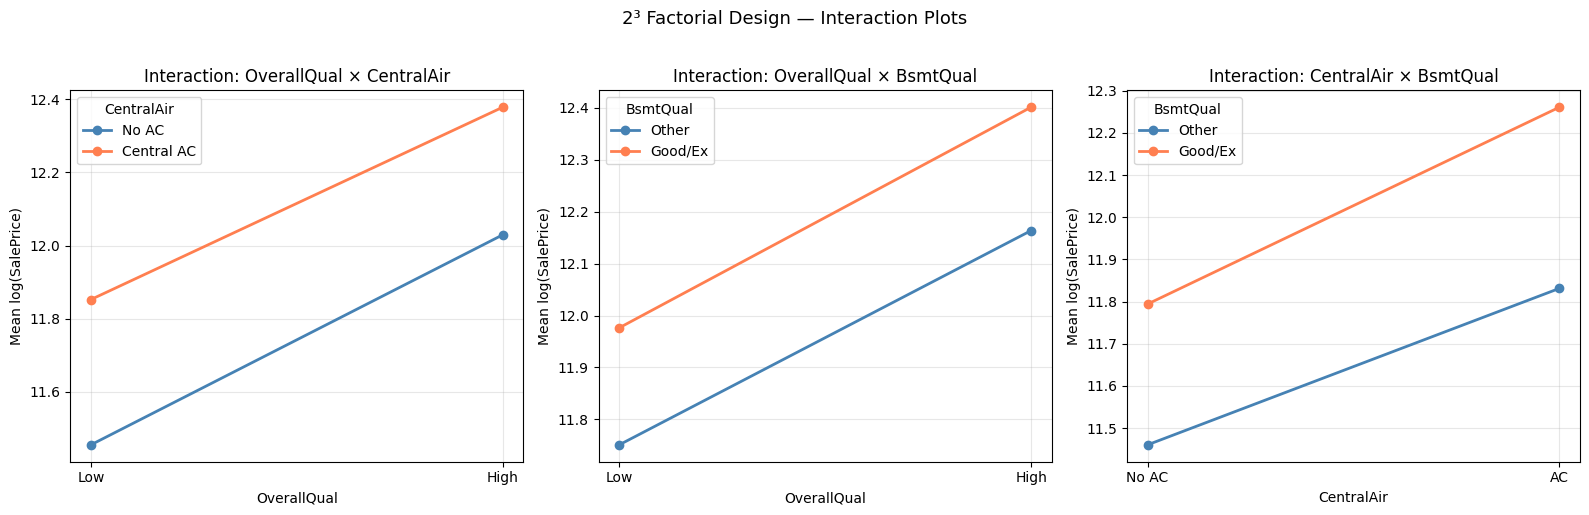

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('A', 'B', 'OverallQual', 'CentralAir',  ['Low','High'], ['No AC','Central AC']),
    ('A', 'C', 'OverallQual', 'BsmtQual',    ['Low','High'], ['Other','Good/Ex']),
    ('B', 'C', 'CentralAir',  'BsmtQual',    ['No AC','AC'], ['Other','Good/Ex']),
]

for ax, (f1, f2, n1, n2, labels1, labels2) in zip(axes, pairs):
    for val2, label2, color in zip([0,1], labels2, ['steelblue','coral']):
        subset = df3[df3[f2] == val2]
        means  = subset.groupby(f1)['LogSalePrice'].mean()
        ax.plot(labels1, means.values, marker='o', label=label2, color=color, linewidth=2)
    ax.set_title(f'Interaction: {n1} × {n2}')
    ax.set_ylabel('Mean log(SalePrice)')
    ax.set_xlabel(n1)
    ax.legend(title=n2)
    ax.grid(True, alpha=0.3)

plt.suptitle('2³ Factorial Design — Interaction Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The interaction plots visualize the two-way interactions between each pair of factors. Parallel lines indicate no interaction both levels of one factor respond similarly to changes in the other. Crossing or diverging lines signal a meaningful interaction effect. For example, if the gap between "Good Basement" and "Other Basement" is much larger for high-quality homes than low-quality ones, it suggests that basement quality matters more when the overall build quality is already high.

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.